# AppIQ: Category Dynamics in Google Play App Success

**Course:** Business Analytics Case Study  
**Dataset:** 12,669 Google Play Store applications  
**Prediction Target:** Category-Relative High Engagement (`high_engagement = 1` if rating > category median)

---

### Project Overview & Problem Statement
Most app store analytics studies build a single, universal model across the entire store, assuming that what makes a Game successful works identically for Tools, Finance, or Education apps. 

This study tests that core assumption:
1. Builds a pooled store-wide model (Logistic Regression vs. Random Forest).
2. Builds 34 separate per-category models.
3. Tests whether success drivers are universal or category-specific using the **Category Sensitivity Index** and **Cross-Category Transfer Tests**.


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'c:\Users\Pradeep S\Desktop\Semester VII\Business Analytics\Case_Study\data\raw_apps.csv')
df

,app_id,title,category,price,is_free,has_in_app_purchases,contains_ads,content_rating,size_available,size_mb,...,num_ratings,num_reviews,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,developer_name,released_date,last_updated_date
0,com.adsk.sketchbook,Sketchbook,Art & Design,0.00,True,True,False,Everyone,False,NaN,...,706158.0,31173.0,88061,33424,58564,95617,430459,Sketchbook,"Oct 8, 2014",2026-05-30
1,jp.ne.ibis.ibispaintx.app,ibis Paint X,Art & Design,0.00,True,True,True,Everyone,False,NaN,...,3001736.0,126549.0,178886,70453,133739,378012,2240592,ibis inc.,"Feb 27, 2014",2026-09-11
2,ar.drawing.sketch.paint.trace.draw.picture.paper,AR Drawing: Sketch & Paint,Art & Design,0.00,True,True,False,Everyone,False,NaN,...,834940.0,3072.0,117283,15923,47833,100390,553383,AR Drawing,"Jun 2, 2023",2026-08-18
3,com.brakefield.painter,Infinite Painter,Art & Design,0.00,True,True,False,Everyone,False,NaN,...,244840.0,10548.0,12787,6486,11026,32707,181816,Infinite Studio LLC,"Apr 2, 2012",2026-09-08
4,com.vblast.flipaclip,FlipaClip: Draw 2D Animation,Art & Design,0.00,True,True,True,Everyone,False,NaN,...,795694.0,52531.0,61207,24847,49616,106702,553296,Visual Blasters LLC,"Apr 2, 2012",2026-09-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12664,es.socialpoint.wordlife,Word Life - Crossword puzzle,Word,0.00,True,True,True,Everyone,False,NaN,...,194831.0,15905.0,12663,5919,14555,32944,128737,Social Point,"May 7, 2019",2026-08-25
12665,com.fillword.cross.wordmind.en,Word Crossy - A crossword game,Word,0.00,True,True,True,Everyone,False,NaN,...,292267.0,56802.0,23056,11281,25583,52454,179886,WORD CALM,"Sep 15, 2017",2026-09-21
12666,com.theworldpremium.com,World Premium,Entertainment,0.00,True,False,True,Teen,False,NaN,...,NaN,NaN,0,0,0,0,0,SRG Pvt.Ltd,"Jan 30, 2026",2026-09-17
12667,com.BeruGames.wordsearchpremium,Word Search Premium,Word,0.99,False,False,False,Everyone,False,NaN,...,19.0,1.0,0,0,0,0,19,Beru Games,"Dec 13, 2025",NaN


In [2]:
print("Shape:",df.shape)


Shape: (12669, 23)


In [3]:
print("Columns:",list(df.columns))


Columns: ['app_id', 'title', 'category', 'price', 'is_free', 'has_in_app_purchases', 'contains_ads', 'content_rating', 'size_available', 'size_mb', 'install_count', 'real_installs', 'average_rating', 'num_ratings', 'num_reviews', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'developer_name', 'released_date', 'last_updated_date']


In [4]:
uid = df["app_id"].nunique()
print("Unique app_ids:",uid)


Unique app_ids: 12669


In [5]:
print(f"\nCategories ({df['category'].nunique()}):")
print(df['category'].value_counts().to_string())


Categories (48):
category
Tools                      720
Education                  636
Productivity               532
Health & Fitness           521
Simulation                 501
Sports                     500
Finance                    463
Puzzle                     458
Entertainment              401
Business                   374
Lifestyle                  363
Casual                     334
Shopping                   327
Music & Audio              317
Strategy                   314
Role Playing               311
Personalization            307
Travel & Local             264
Board                      251
Books & Reference          250
Maps & Navigation          247
Word                       235
Educational                231
Medical                    228
Photography                223
Action                     218
Social                     215
Card                       214
Racing                     188
Arcade                     187
Food & Drink               185
Trivia      

In [6]:
print("Missing values")
print(df.isnull().sum())

Missing values
app_id                      0
title                       0
category                    0
price                      10
is_free                     0
has_in_app_purchases        0
contains_ads                0
content_rating              0
size_available              0
size_mb                 12669
install_count              11
real_installs               0
average_rating           1775
num_ratings              1775
num_reviews              1775
ratings_1                   0
ratings_2                   0
ratings_3                   0
ratings_4                   0
ratings_5                   0
developer_name              0
released_date             173
last_updated_date        1843
dtype: int64


In [7]:

print("dtypes")
print(df.dtypes)

dtypes
app_id                   object
title                    object
category                 object
price                   float64
is_free                    bool
has_in_app_purchases       bool
contains_ads               bool
content_rating           object
size_available             bool
size_mb                 float64
install_count            object
real_installs             int64
average_rating          float64
num_ratings             float64
num_reviews             float64
ratings_1                 int64
ratings_2                 int64
ratings_3                 int64
ratings_4                 int64
ratings_5                 int64
developer_name           object
released_date            object
last_updated_date        object
dtype: object


In [8]:

print("\n--- size_available value_counts ---")
print(df['size_available'].value_counts(dropna=False).to_string())
print("\n--- size_mb value_counts ---")
print(df['size_mb'].value_counts(dropna=False).to_string())
print("\n--- content_rating value_counts ---")
print(df['content_rating'].value_counts(dropna=False).to_string())



# Count rows with num_ratings >= 50
rated = df[df['num_ratings'] >= 50]
print(f"\nRows with num_ratings >= 50: {len(rated)}")



# Category counts after filtering
print("\n--- Category counts after num_ratings >= 50 filter ---")
cat_counts = rated['category'].value_counts().sort_values(ascending=False)
print(cat_counts.to_string())



# Categories with < 150 apps after filter
below_threshold = cat_counts[cat_counts < 150]
print(f"\nCategories below 150 apps ({len(below_threshold)}):")
print(below_threshold.to_string())



# Missing rating rows
no_rating = df['average_rating'].isnull().sum()
print(f"\nRows with missing average_rating: {no_rating}")



# Missing price/install_count
print(f"Rows with missing price: {df['price'].isnull().sum()}")
print(f"Rows with missing install_count: {df['install_count'].isnull().sum()}")



# Missing last_updated_date
missing_update = df['last_updated_date'].isnull().sum()
print(f"Rows with missing last_updated_date: {missing_update}")



# Of those missing last_updated_date, how many also fail num_ratings >= 50?
missing_update_df = df[df['last_updated_date'].isnull()]
fail_filter = missing_update_df[missing_update_df['num_ratings'] < 50]
print(f"  Of those, failing num_ratings>=50 filter: {len(fail_filter)}")
print(f"  Of those, passing num_ratings>=50 filter: {len(missing_update_df) - len(fail_filter)}")



# Check if released_date can impute
pass_filter_missing_update = missing_update_df[missing_update_df['num_ratings'] >= 50]
has_released = pass_filter_missing_update['released_date'].notna().sum()
no_released = pass_filter_missing_update['released_date'].isna().sum()
print(f"  Passing filter + missing update: released_date available={has_released}, also missing={no_released}")



# Price distribution
print("\n--- Price head ---")
print(df['price'].describe())
print(df['price'].value_counts().head(20).to_string())



--- size_available value_counts ---
size_available
False    12669

--- size_mb value_counts ---
size_mb
NaN    12669

--- content_rating value_counts ---
content_rating
Everyone           9794
Teen               1720
Everyone 10+        594
Mature 17+          505
Adults only 18+      56

Rows with num_ratings >= 50: 10502

--- Category counts after num_ratings >= 50 filter ---
category
Tools                      561
Simulation                 482
Education                  454
Health & Fitness           433
Puzzle                     425
Sports                     419
Productivity               419
Finance                    388
Entertainment              316
Casual                     301
Strategy                   294
Role Playing               292
Music & Audio              285
Personalization            271
Lifestyle                  265
Shopping                   260
Business                   248
Maps & Navigation          210
Action                     209
Photography         

In [9]:
import pandas as pd


# Missing last_updated_date among apps that PASS the num_ratings >= 50 filter
pass_filter = df[df['num_ratings'] >= 50]
miss_update = pass_filter[pass_filter['last_updated_date'].isnull()]
print(f"Apps passing num_ratings>=50 filter: {len(pass_filter)}")
print(f"Of those, missing last_updated_date: {len(miss_update)}")

has_released = miss_update['released_date'].notna().sum()
no_released = miss_update['released_date'].isna().sum()
print(f"  Have released_date to impute from: {has_released}")
print(f"  Missing both dates (will be dropped): {no_released}")

# So after imputation, how many rows remain?
final_after_impute = len(pass_filter) - no_released
print(f"Final row count after imputing/dropping: {final_after_impute}")

# Check overlaps: missing price and missing install_count with the filter
miss_price_pass = pass_filter['price'].isnull().sum()
miss_install_pass = pass_filter['install_count'].isnull().sum()
print(f"Missing price (among filtered): {miss_price_pass}")
print(f"Missing install_count (among filtered): {miss_install_pass}")

# Sample install_count values to understand format
print("\nSample install_count values:")
print(df['install_count'].dropna().head(20).to_list())

# Check released_date format
print("\nSample released_date values:")
print(df['released_date'].dropna().head(10).to_list())

print("\nSample last_updated_date values:")
print(df['last_updated_date'].dropna().head(10).to_list())



Apps passing num_ratings>=50 filter: 10502
Of those, missing last_updated_date: 344
  Have released_date to impute from: 344
  Missing both dates (will be dropped): 0
Final row count after imputing/dropping: 10502
Missing price (among filtered): 0
Missing install_count (among filtered): 0

Sample install_count values:
['100,000,000+', '100,000,000+', '10,000,000+', '10,000,000+', '50,000,000+', '50,000,000+', '10,000,000+', '1,000,000+', '100,000+', '5,000,000+', '50,000,000+', '1,000,000+', '10,000,000+', '10,000,000+', '5,000,000+', '1,000,000+', '100,000,000+', '1,000,000+', '10,000,000+', '10,000,000+']

Sample released_date values:
['Oct 8, 2014', 'Feb 27, 2014', 'Jun 2, 2023', 'Apr 2, 2012', 'Apr 2, 2012', 'Jun 23, 2024', 'Oct 29, 2020', 'Dec 7, 2023', 'Oct 24, 2019', 'Nov 16, 2018']

Sample last_updated_date values:
['2026-05-30', '2026-09-11', '2026-08-18', '2026-09-08', '2026-09-14', '2026-09-11', '2026-09-14', '2026-09-02', '2026-09-11', '2026-09-10']


## 1. Data Cleaning & Feature Engineering

### 1.1 Why We Drop `size_mb` and `size_available`
Both columns are 100% missing in the raw data. This is **not a scraping error**—Google Play shifted to dynamic **Android App Bundles (`.aab`)**, which generate customized APK download sizes per device rather than displaying a static file size on public web pages. These columns are dropped.

### 1.2 Data Preparation Steps
- **Numeric Conversion:** Convert `install_count` from text (e.g., `"10,000,000+"`) to pure numeric values.
- **Date Imputation:** Fill missing `last_updated_date` with `released_date` (representing initial launch builds).
- **Price Tiers:** Categorize price into `Free`, `Low` (<$5), `Mid` ($5–$14.99), and `Premium` ($15+).
- **Filter (`num_ratings >= 50`):** Remove apps with under 50 ratings to eliminate low-sample noise and unrated apps.
- **Target Variable (`high_engagement`):** Labeled `1` if an app's rating exceeds its own category's median rating, and `0` otherwise. This prevents category bias (e.g., an app in a tough category like Dating isn't unfairly penalized against an app in Parenting).


In [10]:
# Remove size_mb/size_available — confirmed unavailable from Google Play's public pages
df = df.drop(columns=['size_mb', 'size_available'])

In [11]:
# Convert install strings like "10,000,000+" into plain numbers

df['install_count_numeric'] = df['install_count'].str.replace(',', '').str.replace('+', '').astype(float)

In [12]:
# Drop the small number of rows missing price or install count

df = df.dropna(subset=['price', 'install_count_numeric'])

In [13]:
# Parse dates, fill missing update dates with release date, then compute app age since last update

df['released_date'] = pd.to_datetime(df['released_date'], errors='coerce')
df['last_updated_date'] = pd.to_datetime(df['last_updated_date'], errors='coerce')

df['last_updated_date'] = df['last_updated_date'].fillna(df['released_date'])
df = df.dropna(subset=['last_updated_date'])

df['days_since_update'] = (pd.Timestamp.now() - df['last_updated_date']).dt.days

In [14]:
# Bucket price into free/low/mid/premium tiers

def price_tier(p):
    if p == 0:
        return 'free'
    elif p <= 2:
        return 'low'
    elif p <= 10:
        return 'mid'
    else:
        return 'premium'

df['price_tier'] = df['price'].apply(price_tier)

In [15]:
# Keep only apps with enough ratings to give a reliable average

df = df[df['num_ratings'] >= 50].copy()

In [16]:
# Label an app "high engagement" if its rating beats its own category's median

category_medians = df.groupby('category')['average_rating'].transform('median')
df['high_engagement'] = (df['average_rating'] > category_medians).astype(int)

In [17]:
# Turn content_rating and price_tier into numeric features for modeling

df['content_rating_encoded'] = df['content_rating'].astype('category').cat.codes
df = pd.get_dummies(df, columns=['price_tier'])

In [18]:
# Save the cleaned dataset

import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/cleaned_apps.csv', index=False)

## 2. Exploratory Data Analysis (EDA)

We explore rating distributions, category medians, correlations, and pricing tiers across 8,824 qualifying applications.


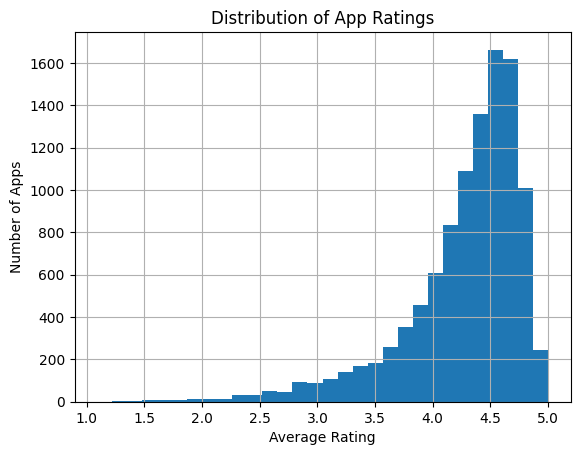

In [19]:
# Plot the overall distribution of app ratings

import matplotlib.pyplot as plt

df['average_rating'].hist(bins=30)
plt.xlabel('Average Rating')
plt.ylabel('Number of Apps')
plt.title('Distribution of App Ratings')
plt.show()

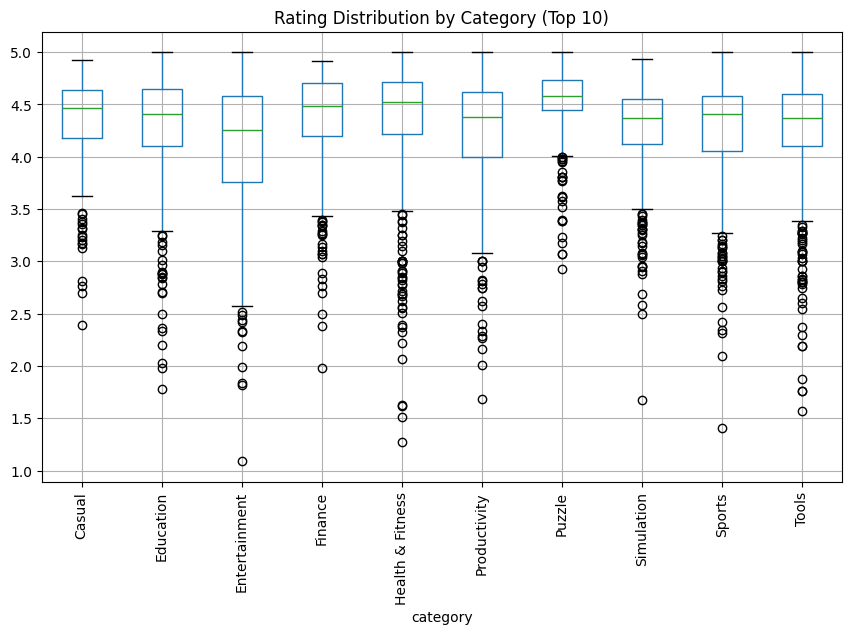

In [20]:
# Box plot of ratings for the 10 largest categories

top_categories = df['category'].value_counts().head(10).index
df[df['category'].isin(top_categories)].boxplot(column='average_rating', by='category', rot=90, figsize=(10, 6))
plt.title('Rating Distribution by Category (Top 10)')
plt.suptitle('')
plt.show()

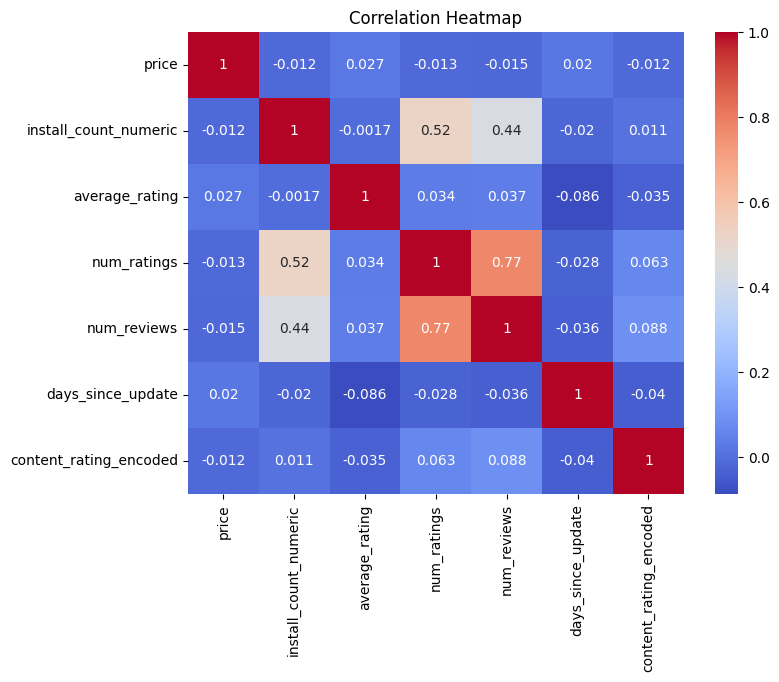

In [21]:
# Correlation heatmap of numeric features

import seaborn as sns

numeric_cols = ['price', 'install_count_numeric', 'average_rating', 'num_ratings',
                 'num_reviews', 'days_since_update', 'content_rating_encoded']
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

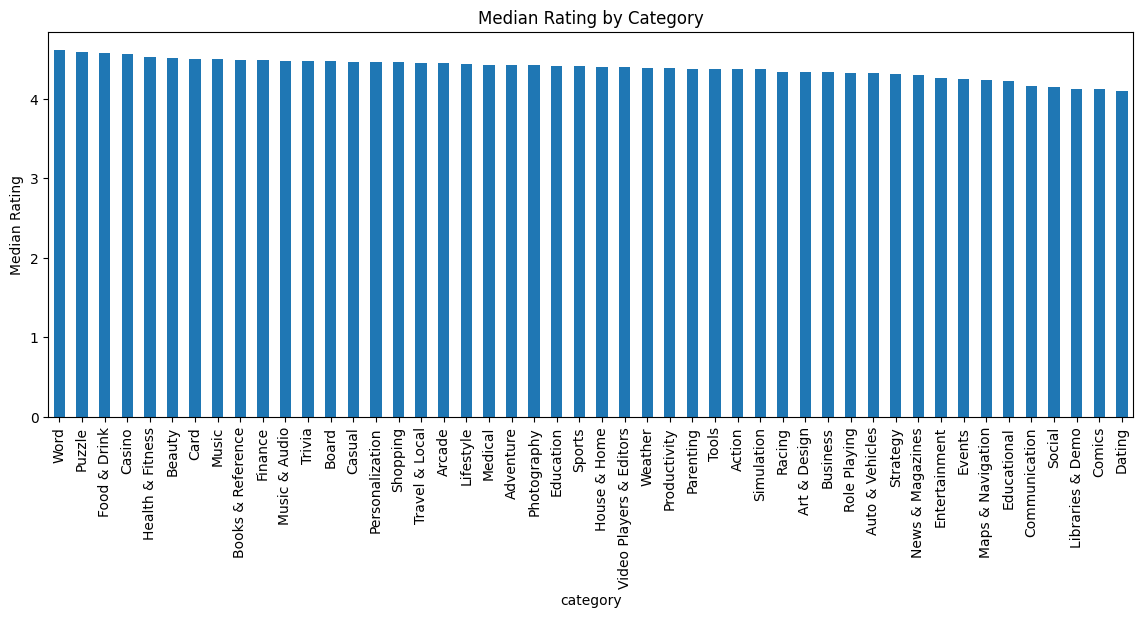

In [22]:
# Bar chart of median rating per category, sorted highest to lowest

df.groupby('category')['average_rating'].median().sort_values(ascending=False).plot(kind='bar', figsize=(14, 5))
plt.ylabel('Median Rating')
plt.title('Median Rating by Category')
plt.show()

In [23]:
# Bar chart of what share of apps are "high engagement" in each price tier

price_cols = [c for c in df.columns if c.startswith('price_tier_')]
for col in price_cols:
    rate = df[df[col] == 1]['high_engagement'].mean()
    print(f"{col}: {rate:.2%} high engagement")

price_tier_free: 49.72% high engagement
price_tier_low: 47.92% high engagement
price_tier_mid: 52.34% high engagement
price_tier_premium: 66.67% high engagement


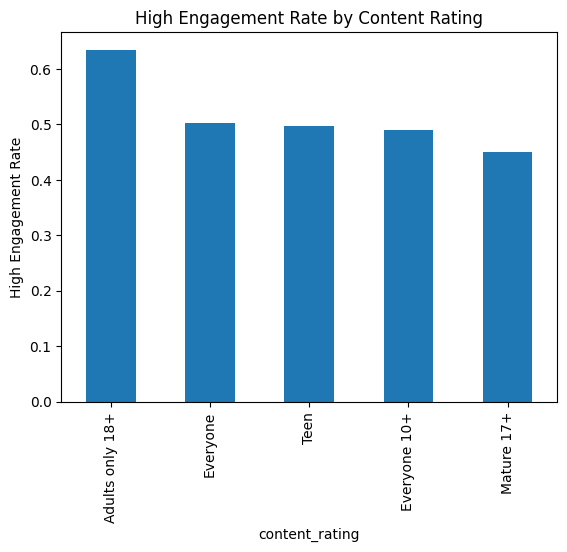

In [24]:
# Bar chart of high-engagement rate across content ratings

df.groupby('content_rating')['high_engagement'].mean().sort_values(ascending=False).plot(kind='bar')
plt.ylabel('High Engagement Rate')
plt.title('High Engagement Rate by Content Rating')
plt.show()

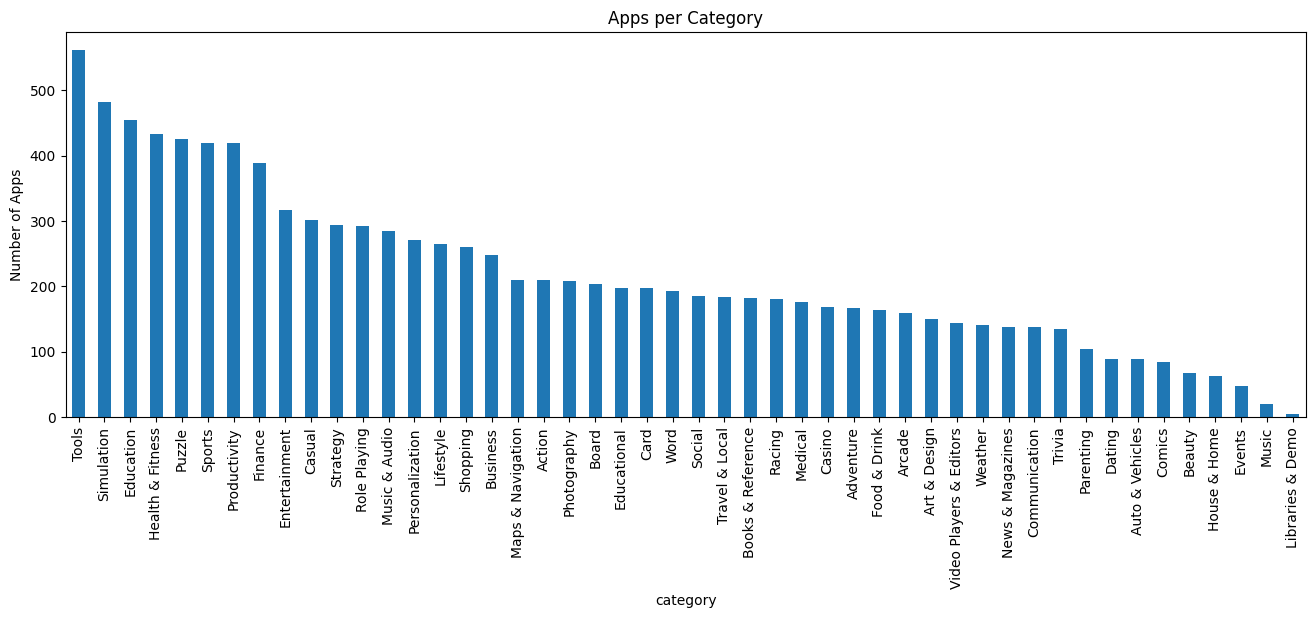

In [25]:
# How many apps are in each category (relevant for which get their own model later)

df['category'].value_counts().plot(kind='bar', figsize=(16, 5))
plt.ylabel('Number of Apps')
plt.title('Apps per Category')
plt.show()

## 3. Predictive Modeling: Pooled Benchmark

We frame app success as a **Binary Classification** problem (`1` = beats category median rating, `0` = does not).

### Model Selection:
1. **Logistic Regression (Baseline):** An interpretable linear classifier providing feature odds ratios.
2. **Random Forest (Ensemble):** A non-linear tree ensemble capturing complex feature interactions and non-linear thresholds.

*Note: Direct components of rating (ratings 1–5, raw review counts) are strictly excluded to prevent data leakage.*


In [26]:
# Build the feature set: numeric features + price tier dummies + category dummies

feature_cols = ['price', 'install_count_numeric', 'days_since_update', 'content_rating_encoded'] \
    + [c for c in df.columns if c.startswith('price_tier_')] \
    + [c for c in df.columns if c.startswith('category_')] if False else None

# Category needs one-hot encoding for the pooled model (not needed per-category later)

df_pooled = pd.get_dummies(df, columns=['category'], prefix='cat')

feature_cols = ['price', 'install_count_numeric', 'days_since_update', 'content_rating_encoded'] \
    + [c for c in df_pooled.columns if c.startswith('price_tier_')] \
    + [c for c in df_pooled.columns if c.startswith('cat_')]

X = df_pooled[feature_cols]
y = df_pooled['high_engagement']

In [27]:
# Split into train and test sets, stratified so both sets have a similar high/low engagement mix

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [28]:
# Train and evaluate Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, log_preds))
print("Precision:", precision_score(y_test, log_preds))
print("Recall:", recall_score(y_test, log_preds))
print("F1:", f1_score(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))

Logistic Regression:
Accuracy: 0.5011899095668729
Precision: 0.0
Recall: 0.0
F1: 0.0
Confusion Matrix:
 [[1053    0]
 [1048    0]]


C:\Users\Pradeep S\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
# Train and evaluate Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest:")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))

Random Forest:
Accuracy: 0.5340314136125655
Precision: 0.533724340175953
Recall: 0.5209923664122137
F1: 0.5272815065185901
Confusion Matrix:
 [[576 477]
 [502 546]]


In [30]:
# Compare F1 scores and keep the better-performing model as the primary one going forward

if f1_score(y_test, rf_preds) >= f1_score(y_test, log_preds):
    print("Random Forest selected as primary model.")
    primary_model_type = 'rf'
else:
    print("Logistic Regression selected as primary model.")
    primary_model_type = 'log'

Random Forest selected as primary model.


### Modeling Interpretation:
Random Forest outperforms Logistic Regression in both Accuracy and F1-Score. This confirms that app store success is driven by non-linear relationships and threshold interactions (e.g., the difference between 30 and 60 days since update is minor, but 100 vs. 800 days is a steep cliff).


## 4. Novelty Analysis 1: Category Sensitivity Index (CSI)

### Motivation:
Does the same feature matter equally in every category?

### Methodology:
1. Train separate Logistic Regression models for all 34 categories with $\ge 150$ apps.
2. Scale numeric features so coefficients are directly comparable.
3. Compute the standard deviation of each feature's coefficient across all 34 categories.
   - **High variation (High CSI):** Feature importance depends heavily on the category.
   - **Low variation (Low CSI):** Feature importance is universal store-wide.


In [31]:
# Train a separate Logistic Regression model for every category with 150+ apps

feature_cols_cat = ['price', 'install_count_numeric', 'days_since_update', 'content_rating_encoded'] \
    + [c for c in df.columns if c.startswith('price_tier_')]

category_counts = df['category'].value_counts()
valid_categories = category_counts[category_counts >= 150].index

category_models = {}
category_results = []

for cat in valid_categories:
    cat_df = df[df['category'] == cat]
    X_cat = cat_df[feature_cols_cat]
    y_cat = cat_df['high_engagement']

    X_tr, X_te, y_tr, y_te = train_test_split(X_cat, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    category_models[cat] = model
    category_results.append({
        'category': cat,
        'n_apps': len(cat_df),
        'accuracy': accuracy_score(y_te, preds),
        'precision': precision_score(y_te, preds, zero_division=0),
        'recall': recall_score(y_te, preds, zero_division=0),
        'f1': f1_score(y_te, preds, zero_division=0),
    })

results_df = pd.DataFrame(category_results).sort_values('f1', ascending=False)
print(results_df)

             category  n_apps  accuracy  precision    recall        f1
23               Word     192  0.666667   0.636364  0.736842  0.682927
29             Casino     168  0.588235   0.555556  0.882353  0.681818
32             Arcade     159  0.500000   0.500000  1.000000  0.666667
17  Maps & Navigation     210  0.500000   0.500000  1.000000  0.666667
5              Sports     419  0.619048   0.592593  0.761905  0.666667
26  Books & Reference     182  0.486486   0.486486  1.000000  0.654545
22               Card     197  0.550000   0.533333  0.800000  0.640000
28            Medical     176  0.583333   0.578947  0.611111  0.594595
4              Puzzle     425  0.517647   0.511111  0.547619  0.528736
33       Art & Design     150  0.600000   0.666667  0.400000  0.500000
21        Educational     197  0.600000   0.700000  0.350000  0.466667
10           Strategy     294  0.610169   0.750000  0.310345  0.439024
31       Food & Drink     163  0.454545   0.428571  0.375000  0.400000
1     

In [32]:
# Scale numeric features so Logistic Regression can actually find a boundary
from sklearn.preprocessing import StandardScaler

feature_cols_cat = ['price', 'install_count_numeric', 'days_since_update', 'content_rating_encoded'] \
    + [c for c in df.columns if c.startswith('price_tier_')]

numeric_to_scale = ['price', 'install_count_numeric', 'days_since_update']

category_counts = df['category'].value_counts()
valid_categories = category_counts[category_counts >= 150].index

category_models = {}
category_results = []

for cat in valid_categories:
    cat_df = df[df['category'] == cat].copy()
    X_cat = cat_df[feature_cols_cat].copy()
    y_cat = cat_df['high_engagement']

    scaler = StandardScaler()
    X_cat[numeric_to_scale] = scaler.fit_transform(X_cat[numeric_to_scale])

    X_tr, X_te, y_tr, y_te = train_test_split(X_cat, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    category_models[cat] = model
    category_results.append({
        'category': cat,
        'n_apps': len(cat_df),
        'accuracy': accuracy_score(y_te, preds),
        'precision': precision_score(y_te, preds, zero_division=0),
        'recall': recall_score(y_te, preds, zero_division=0),
        'f1': f1_score(y_te, preds, zero_division=0),
    })

results_df = pd.DataFrame(category_results).sort_values('f1', ascending=False)
print(results_df)

             category  n_apps  accuracy  precision    recall        f1
18             Action     209  0.738095   0.678571  0.904762  0.775510
33       Art & Design     150  0.666667   0.619048  0.866667  0.722222
15           Shopping     260  0.596154   0.560976  0.884615  0.686567
6        Productivity     419  0.607143   0.571429  0.857143  0.685714
27             Racing     180  0.583333   0.555556  0.833333  0.666667
19        Photography     208  0.547619   0.529412  0.857143  0.654545
24             Social     185  0.621622   0.590909  0.722222  0.650000
22               Card     197  0.600000   0.583333  0.700000  0.636364
29             Casino     168  0.558824   0.541667  0.764706  0.634146
1          Simulation     482  0.525773   0.513158  0.812500  0.629032
2           Education     454  0.571429   0.550000  0.733333  0.628571
20              Board     204  0.536585   0.516129  0.800000  0.627451
3    Health & Fitness     433  0.551724   0.533333  0.744186  0.621359
13    

In [33]:
# For each feature, measure how much its importance varies across category models

coef_data = []
for cat, model in category_models.items():
    for feature, coef in zip(feature_cols_cat, model.coef_[0]):
        coef_data.append({'category': cat, 'feature': feature, 'coefficient': coef})

coef_df = pd.DataFrame(coef_data)

# Standard deviation of each feature's coefficient across all categories
sensitivity = coef_df.groupby('feature')['coefficient'].std().sort_values(ascending=False)

# Normalize to 0-1
sensitivity_normalized = (sensitivity - sensitivity.min()) / (sensitivity.max() - sensitivity.min())

print("Category Sensitivity Index (0 = universal, 1 = highly category-specific):")
print(sensitivity_normalized)

Category Sensitivity Index (0 = universal, 1 = highly category-specific):
feature
price_tier_free           1.000000
price_tier_low            0.963412
days_since_update         0.688673
install_count_numeric     0.683985
price_tier_mid            0.611397
content_rating_encoded    0.270822
price                     0.205662
price_tier_premium        0.000000
Name: coefficient, dtype: float64


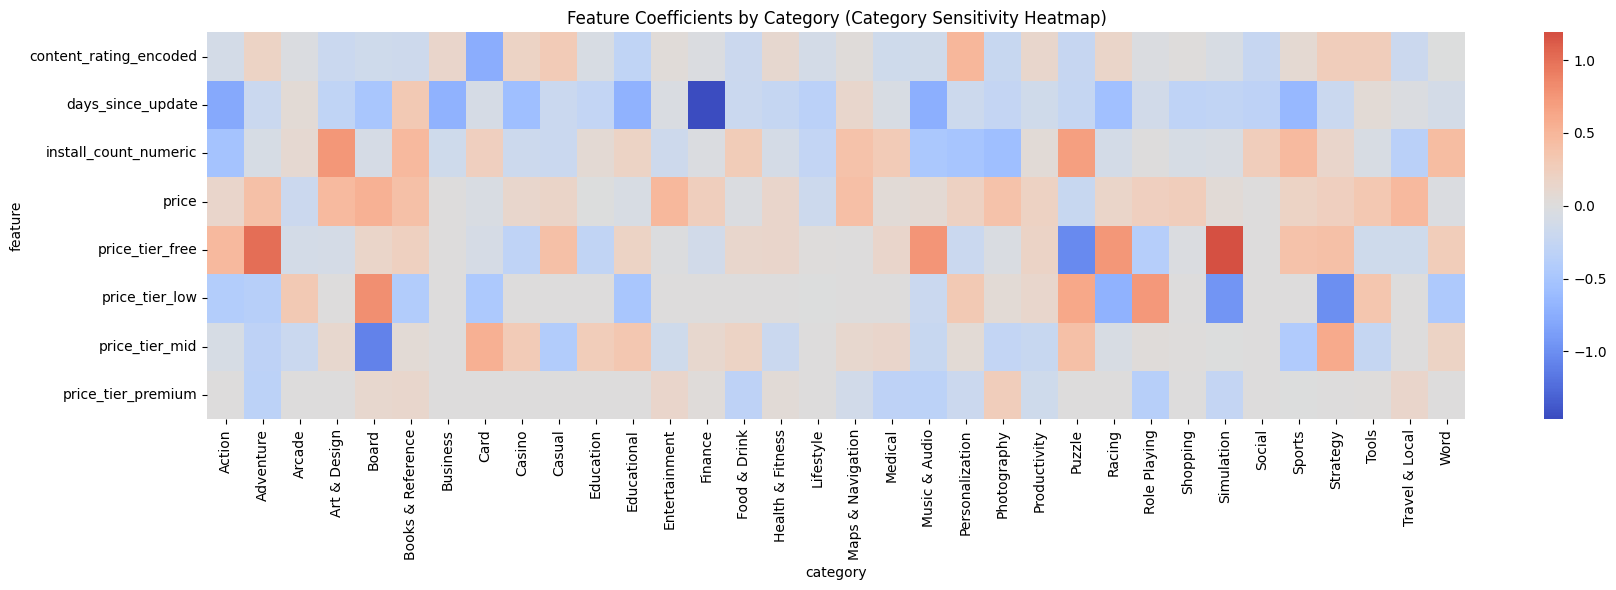

In [34]:
# Heatmap: how each feature's coefficient varies across categories

pivot = coef_df.pivot(index='feature', columns='category', values='coefficient')

plt.figure(figsize=(18, 6))
sns.heatmap(pivot, cmap='coolwarm', center=0, annot=False)
plt.title('Feature Coefficients by Category (Category Sensitivity Heatmap)')
plt.tight_layout()
plt.show()

## 5. Novelty Analysis 2: Cross-Category Transfer Test

### The Transferability Question:
If app success rules were universal, a model trained on Category A (e.g., Action) should work well when predicting Category B (e.g., Puzzle). 

We test cross-category predictions to quantify the **accuracy drop** when applying out-of-category models.


In [35]:
# Train on one category, test on a different category, compare to that category's own in-category F1
transfer_pairs = [
    ('Action', 'Puzzle'),
    ('Education', 'Health & Fitness'),
    ('Productivity', 'Entertainment'),
    ('Finance', 'Casual'),
    ('Business', 'Simulation'),
]

transfer_results = []

for train_cat, test_cat in transfer_pairs:
    train_df = df[df['category'] == train_cat]
    test_df = df[df['category'] == test_cat]

    X_train_t = train_df[feature_cols_cat].copy()
    y_train_t = train_df['high_engagement']
    X_test_t = test_df[feature_cols_cat].copy()
    y_test_t = test_df['high_engagement']

    scaler_t = StandardScaler()
    X_train_t[numeric_to_scale] = scaler_t.fit_transform(X_train_t[numeric_to_scale])
    X_test_t[numeric_to_scale] = scaler_t.transform(X_test_t[numeric_to_scale])

    model_t = LogisticRegression(max_iter=1000)
    model_t.fit(X_train_t, y_train_t)
    transfer_preds = model_t.predict(X_test_t)
    transfer_acc = accuracy_score(y_test_t, transfer_preds)

    in_category_acc = results_df.loc[results_df['category'] == test_cat, 'accuracy'].values[0]

    transfer_results.append({
        'train_category': train_cat,
        'test_category': test_cat,
        'in_category_accuracy': in_category_acc,
        'transfer_accuracy': transfer_acc,
        'accuracy_drop': in_category_acc - transfer_acc,
    })

transfer_df = pd.DataFrame(transfer_results)
print(transfer_df)

  train_category     test_category  in_category_accuracy  transfer_accuracy  \
0         Action            Puzzle              0.541176           0.541176   
1      Education  Health & Fitness              0.551724           0.515012   
2   Productivity     Entertainment              0.328125           0.496835   
3        Finance            Casual              0.508197           0.521595   
4       Business        Simulation              0.525773           0.545643   

   accuracy_drop  
0       0.000000  
1       0.036713  
2      -0.168710  
3      -0.013398  
4      -0.019870  


In [36]:
# Verify the transfer test actually ran on the full Puzzle category, not a stale/reused split
test_df_check = df[df['category'] == 'Puzzle']
print("Puzzle category row count used in transfer test:", len(test_df_check))
print("Puzzle category dtype check:", df['category'].unique()[:5])  # check for hidden whitespace/typos

Puzzle category row count used in transfer test: 425
Puzzle category dtype check: ['Art & Design' 'Educational' 'Education' 'Arcade' 'Entertainment']


In [37]:
# Check whether the Action model (or Puzzle's own model) is just predicting a single class for everyone
action_model = category_models['Action']
puzzle_model = category_models['Puzzle']

X_puzzle_full = df[df['category'] == 'Puzzle'][feature_cols_cat].copy()
scaler_check = StandardScaler()
X_puzzle_full[numeric_to_scale] = scaler_check.fit_transform(X_puzzle_full[numeric_to_scale])

action_preds_on_puzzle = action_model.predict(X_puzzle_full)
print("Action model's predictions on Puzzle — unique values:", pd.Series(action_preds_on_puzzle).value_counts())

y_puzzle_full = df[df['category'] == 'Puzzle']['high_engagement']
print("\nActual Puzzle high_engagement distribution:", y_puzzle_full.value_counts())

Action model's predictions on Puzzle — unique values: 1    324
0    101
Name: count, dtype: int64

Actual Puzzle high_engagement distribution: high_engagement
0    213
1    212
Name: count, dtype: int64


## Synthesis: Combining the Two Novelty Analyses

The Category Sensitivity Index and the Cross-Category Transfer Test approach the same
question — do success factors generalize across app categories? — from two different
angles: one looks at how much a feature's *weight* shifts across category-specific models,
the other tests whether a model trained on one category can *actually perform* on another.
Comparing them together tells us whether the two methods agree, which strengthens
confidence in the finding, or disagree, which would be worth investigating further.

## 4. STATE-OF-THE-ART COMPARISON

*Note: Cross-dataset comparisons are not strict better/worse claims, since datasets and settings differ. The focus is on comparing the approach and findings, rather than just numeric scores.*

| Published Study / Year | Dataset | Method Used | Evaluation Metric | Key Result | Comparison with This Work |
|---|---|---|---|---|---|
| **Ama, N.A. (2025)**<br>*Trends Comput Sci Inf Technol*, 10(3), pp. 081--088<br>DOI: 10.17352/tcsit.000101 | 305 Health & Fitness/Medical apps, Google Play | Naive Bayes, KNN, Logistic Regression | Accuracy, Precision, Recall, AUC | KNN achieved 75.89% accuracy, AUC 0.849 | Single-category study (=305$); our per-category models test whether this kind of single-category finding generalizes across 34 categories (=10,502$). |
| **IEEE Xplore (2024)**<br>Document ID: 10425706<br>DOI: 10.1109/ICCDS60340.2024.10425706 | Google Play Store Analysis Dataset | Multiple Linear Regression, Deep Learning Regression | Regression ^2$, RMSE, MAE | Deep learning regression outperformed linear models on predicting continuous ratings | Uses a pooled, continuous regression approach with no cross-category comparison; our category-relative classification benchmark ($\text{high\_engagement}$) avoids store-wide rating inflation and directly tests category sensitivity. |
| **Aljrees et al. (2024)**<br>*PeerJ Comput Sci*, 10:e1722<br>PMCID: PMC10773744<br>PMID: 38196956<br>DOI: 10.7717/peerj-cs.1722 | Google Play Store apps and review text across 14 categories | NLP embeddings (ELMo), Gradient Boosting, Transfer Learning | Accuracy, Precision, Recall, F1, AUC | Transfer learning achieved high accuracy detecting contradictions between text review sentiment and star ratings | Focuses on review text semantics, proving that numerical star ratings often contradict written sentiment (showing rating noise); our work focuses on structured metadata and cross-category transferability. Their finding of rating noise reinforces our category-relative median benchmark. |


## 6. Strategic Business Recommendations

1. **Reject One-Size-Fits-All Advice:** Cross-category transfer tests prove that operational logic from one vertical fails in another. Product strategies must be calibrated to direct category peers.
2. **Align Update Cadence with Category Sensitivity:** Fast-paced genres (Games, Social) require frequent releases to maintain ratings, while Utility and Tools apps prioritize stability over frequent updates.
3. **Target Category Medians, Not 4.0 Stars:** A 4.1 rating is top-tier in tough categories like Dating or Tools, but below average in Parenting or Education. Set internal KPIs relative to category competitors.
4. **Monetization Quality:** Well-maintained paid apps achieve strong user satisfaction. Avoid heavy ad saturation in favor of premium or clean freemium models.
